In [2]:
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [259]:
library(tidyverse)
library(ggplot2)
library(ggpubr)
library(readr)
library(survival)
library(survminer)
library(stringr)
library(colorBlindness)
library(Statial)
library(rstatix)
library(ComplexHeatmap)
library(circlize)
library(spatstat.geom)
library(spatstat.model)
library(jsonlite)
library(reticulate)
library(data.table)
library(scales)
library(data.table)
library(cowplot)
library(patchwork)

## Results dir

In [4]:
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

# Palette

In [323]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

# Survival group colors
surv_colors <- c(
  "Short-term survivor" = "#E07B7B",
  "Long-term survivor"  = "#6BAED6"
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

# Loading Primary dataset

In [328]:
celltype_metadata <- readr::read_csv(
  paste0(results_dir, "/celltype_metadata_final.csv")
) %>%
  filter(!patient_exp %in% c("NMC_6_ROI6", "NMC_12_ROI6", "NMC_21_ROI23")) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate("patient_ID" = str_replace(patient_ID, "NMC", "NUT"),
         "patient_exp" = str_replace(patient_exp, "NMC", "NUT"))

#patient exp are written basically like this: NUT_2_ROI3 etc.. let's arrange them properly so based on patient number and then ROI number and extract that order
celltype_metadata <- celltype_metadata %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 578608 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): cell_type, cell_category, patient_ID, exp_name, patient_exp, sample...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months
lgl (1): is_sample_primary

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [329]:
survival_df <- read.csv(
    paste0(results_dir, "/survival_data.csv")
) %>%
#add a factor order for tumor_site column
mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")),
patient_ID = factor(patient_ID, levels = patient_ID_order),
is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
survival_group = ifelse(survival_time_months > 6, "Long-term survivor", "Short-term survivor"),
    event = as.numeric(event),
    survival_time_months = as.numeric(survival_time_months)
  )

survival_df_order <- survival_df %>%
mutate(tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic"))) %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) 

 patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [336]:
#showcase proportions of celltypes per patient_exp in a stacked barplot
celltype_percentage_exp <- celltype_metadata %>%
  select(patient_exp, patient_ID, cell_category_simplified, cell_category) %>%
  group_by(patient_exp, patient_ID, cell_category_simplified, cell_category) %>%
  summarise(cell_count = n()) %>%
  ungroup() %>%
  group_by(patient_exp, patient_ID) %>%
  mutate(
    proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
    percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
    geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
    clr = log(proportion / geom_mean)
  ) %>%
  ungroup()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID,
  cell_category_simplified, and cell_category.
ℹ Output is grouped by patient_exp, patient_ID, and cell_category_simplified.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category_simplified,
  cell_category))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


In [337]:
#get percentages of cell types per patient
cellgroup_percentage_patient = celltype_percentage_exp %>%
  group_by(patient_exp, patient_ID, cell_category_simplified) %>%
  #get the sum of the cell_category_simplified percentages
    summarise(cell_count = sum(cell_count)) %>%
    ungroup() %>%
    group_by(patient_exp, patient_ID) %>%
    mutate(
        proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
        percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
        geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
        clr = log(proportion / geom_mean)
      ) %>%
    ungroup() %>%
    group_by(patient_ID, cell_category_simplified) %>%
    summarise(percentage = median(percentage),
              clr = median(clr)) %>%
    ungroup()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category_simplified.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category_simplified))`
  for per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category_simplified.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category_simplified))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


In [340]:
#get percentages of cell types per patient
celltype_percentage_patient = celltype_percentage_exp %>%
  group_by(patient_exp, patient_ID, cell_category, cell_category_simplified) %>%
  #get the sum of the cell_category_simplified percentages
    summarise(cell_count = sum(cell_count)) %>%
    ungroup() %>%
    group_by(patient_exp, patient_ID) %>%
    mutate(
        proportion = ifelse(cell_count == 0, NA, cell_count / sum(cell_count)),
        percentage = ifelse(cell_count == 0, NA, (cell_count / sum(cell_count)) * 100),
        geom_mean = exp(mean(log(proportion), na.rm = TRUE)), 
        clr = log(proportion / geom_mean)
      ) %>%
    ungroup() %>%
    group_by(patient_ID, cell_category, cell_category_simplified) %>%
    summarise(percentage = median(percentage),
              clr = median(clr)) %>%
    ungroup()
celltype_percentage_patient

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, cell_category,
  and cell_category_simplified.
ℹ Output is grouped by patient_exp, patient_ID, and cell_category.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category,
  cell_category_simplified))` for per-operation grouping (`?dplyr::dplyr_by`)
  instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, cell_category, and
  cell_category_simplified.
ℹ Output is grouped by patient_ID and cell_category.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category, cell_category_simplified))`
  for per-operation grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,cell_category_simplified,percentage,clr
<fct>,<chr>,<fct>,<dbl>,<dbl>
NUT_1,Actin+ cells,Non-immune,4.58263187,1.59803591
NUT_1,B cells,Lymphoid,0.25694590,-1.50747325
NUT_1,CD4+ T cells,Lymphoid,0.55026332,-0.39701972
NUT_1,CD8+ T cells,Lymphoid,1.21758193,0.18322412
NUT_1,DCs,Myeloid,0.02534020,-3.47338607
NUT_1,Endothelial cells,Non-immune,3.26263729,1.15760573
NUT_1,Granulocytes,Myeloid,0.03851657,-3.36181429
NUT_1,Lymphatic endothelial cells,Non-immune,2.05106406,0.32722139
NUT_1,M1 macrophages,Myeloid,1.33385094,0.46866681


# Figure 1

## A - Cell type proportions across ROIs

In [ ]:
#showcase proportions of celltypes per patient_exp in a stacked barplot
celltype_proportions_exp <- celltype_metadata %>%
  select(patient_exp, cell_category) %>%
  group_by(patient_exp, cell_category) %>%
  summarise(cell_count = n()) %>%
  ungroup() %>%
  group_by(patient_exp) %>%
  mutate(percentage = (cell_count / sum(cell_count)) * 100) %>%
  ungroup()

In [ ]:
celltype_proportions_exp_plot = ggplot(
  celltype_proportions_exp,
  aes(x = patient_exp, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient ROI",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 105), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 20, colour = "black"),
    axis.text.x = element_text(size = 20, colour = "black", angle = 45, hjust = 1),
    axis.title.y = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.ticks.y.right = element_blank(),
    axis.title.y.right = element_blank(),
    axis.text.y.right = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
celltype_proportions_exp_plot
ggsave(filename = "/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig1/celltype_proportions_barplot.pdf",
       plot = celltype_proportions_exp_plot,
       width = 12,
       height = 7,
       dpi = 300)

## B- Pearson Correlation of cell types CLRs across ROIs

In [134]:
#calculate celltype_proportions per patient_exp 
celltype_counts_exp <- celltype_metadata %>%
select(patient_exp, cell_category) %>%
group_by(patient_exp, cell_category) %>%
summarise(cell_count = n()) %>%
ungroup()

#Pivot wider for CLR
celltype_counts_wide <- celltype_counts_exp %>%
  pivot_wider(
    names_from = cell_category,
    values_from = cell_count,
    values_fill = 0
  ) %>%
  mutate(across(where(is.numeric), ~ .x + 1))

#Apply CLR per patient_exp
celltype_counts_clr <- celltype_counts_wide %>%
  rowwise() %>%
  mutate(across(where(is.numeric), ~ log(.x / exp(mean(log(c_across(where(is.numeric))))))))

#compute correlations between patient_exps based on their celltypes CLRs
celltype_clr_matrix <- celltype_counts_clr %>%
  select(-patient_exp) %>%
  as.matrix()
cor_matrix <- cor(t(celltype_clr_matrix), method = "pearson")
#add the patient_exp names as row and column names to the correlation matrix
rownames(cor_matrix) <- celltype_counts_clr$patient_exp
colnames(cor_matrix) <- celltype_counts_clr$patient_exp
#make self correlations NA
diag(cor_matrix) <- NA
cor_matrix

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp and cell_category.
ℹ Output is grouped by patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


,NUT_1_ROI1,NUT_1_ROI3,NUT_2_ROI1,NUT_4_ROI9,NUT_5_ROI10,NUT_5_ROI11,NUT_6_ROI5,NUT_7_ROI13,NUT_7_ROI14,NUT_8_ROI17,⋯,NUT_9_ROI4,NUT_12_ROI5,NUT_13_ROI14,NUT_13_ROI15,NUT_14_ROI8,NUT_14_ROI11,NUT_15_ROI7,NUT_15_ROI16,NUT_16_ROI17,NUT_16_ROI19
NUT_1_ROI1,NA,0.9278618,0.5366316,0.6159844,0.3995893,0.4317903,0.31357847,0.78409591,0.7720869,0.6888469,⋯,0.66051546,0.7325922,0.8381999,0.8090916,0.7691388,0.6661846,0.5539249,0.4757684,0.62508895,0.67348699
NUT_1_ROI3,0.9278618,NA,0.5397242,0.6356673,0.4048268,0.4355987,0.14175666,0.76502861,0.7282708,0.6189781,⋯,0.63601209,0.7640067,0.8791523,0.8150600,0.7924158,0.7446298,0.5561372,0.4721678,0.60506162,0.77583716
NUT_2_ROI1,0.5366316,0.5397242,NA,0.8010099,0.8389304,0.8868251,0.31774510,0.73529080,0.6596090,0.6506291,⋯,0.25841059,0.3613751,0.4751184,0.5094683,0.6391324,0.5306663,0.7615979,0.7884198,0.36816646,0.69191931
NUT_4_ROI9,0.6159844,0.6356673,0.8010099,NA,0.6665754,0.7055905,0.12558060,0.84210568,0.7475235,0.8580608,⋯,0.60323185,0.5812358,0.5119831,0.5572473,0.7921358,0.6602206,0.6556145,0.5950287,0.67643608,0.82491654
NUT_5_ROI10,0.3995893,0.4048268,0.8389304,0.6665754,NA,0.8886405,0.33351016,0.48744396,0.4957830,0.5634838,⋯,0.29208947,0.3100852,0.4516715,0.4857956,0.4627455,0.4879582,0.8300073,0.7407469,0.38913284,0.53897124
NUT_5_ROI11,0.4317903,0.4355987,0.8868251,0.7055905,0.8886405,NA,0.24120976,0.64076938,0.5878080,0.5716557,⋯,0.24505114,0.2371057,0.4291548,0.4581708,0.4244141,0.3924431,0.7782424,0.7369628,0.35556588,0.51179625
NUT_6_ROI5,0.3135785,0.1417567,0.3177451,0.1255806,0.3335102,0.2412098,NA,0.08787252,0.1535619,0.1684415,⋯,0.09437449,0.3981252,0.2171775,0.2618344,0.3449783,0.3165376,0.3393832,0.4572667,0.08153907,0.05658586
NUT_7_ROI13,0.7840959,0.7650286,0.7352908,0.8421057,0.4874440,0.6407694,0.08787252,NA,0.9041390,0.8162254,⋯,0.61401566,0.5804686,0.7004304,0.7396899,0.8242901,0.7046066,0.5463669,0.5006901,0.70550196,0.78114270
NUT_7_ROI14,0.7720869,0.7282708,0.6596090,0.7475235,0.4957830,0.5878080,0.15356190,0.90413895,NA,0.8328203,⋯,0.59730508,0.6464713,0.6788966,0.7856432,0.8108047,0.7187400,0.4817471,0.4021539,0.69840047,0.72723885
NUT_8_ROI17,0.6888469,0.6189781,0.6506291,0.8580608,0.5634838,0.5716557,0.16844146,0.81622535,0.8328203,NA,⋯,0.74671186,0.5257919,0.6038625,0.7007452,0.7656096,0.6885292,0.5906120,0.4735047,0.82221619,0.75703823


In [135]:
#Build a heatmap of the correlation matrix using ComplexHeatmap
cor_matrix_main_ht <- Heatmap(cor_matrix, 
        name = "Pearson Correlation", 
        show_row_names = TRUE, 
        col = colorRamp2(c(0, 0.5, 1), c("blue", "white", "red")),
        show_column_names = TRUE,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        row_names_gp = gpar(fontsize = 13),
        column_names_gp = gpar(fontsize = 13))
pdf("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig1/correlation_heatmap.pdf", width = 8, height = 6)
draw(cor_matrix_main_ht)
dev.off()


agg_record_1476160405 
                    2

In [136]:
#for cor_matrix, make every value NA except the ones whos column name and rowname has the same "NUT_"
cor_matrix_same_patient <- cor_matrix
for (i in 1:nrow(cor_matrix_same_patient)) {
  for (j in 1:ncol(cor_matrix_same_patient)) {
    if (str_extract(rownames(cor_matrix_same_patient)[i], "(?<=NUT_)\\d+") != str_extract(colnames(cor_matrix_same_patient)[j], "(?<=NUT_)\\d+")) {
      cor_matrix_same_patient[i, j] <- NA
    }
  }
}
cor_matrix_same_patient

,NUT_1_ROI1,NUT_1_ROI3,NUT_2_ROI1,NUT_4_ROI9,NUT_5_ROI10,NUT_5_ROI11,NUT_6_ROI5,NUT_7_ROI13,NUT_7_ROI14,NUT_8_ROI17,⋯,NUT_9_ROI4,NUT_12_ROI5,NUT_13_ROI14,NUT_13_ROI15,NUT_14_ROI8,NUT_14_ROI11,NUT_15_ROI7,NUT_15_ROI16,NUT_16_ROI17,NUT_16_ROI19
NUT_1_ROI1,NA,0.9278618,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_1_ROI3,0.9278618,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_2_ROI1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_4_ROI9,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_5_ROI10,NA,NA,NA,NA,NA,0.8886405,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_5_ROI11,NA,NA,NA,NA,0.8886405,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_6_ROI5,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_7_ROI13,NA,NA,NA,NA,NA,NA,NA,NA,0.904139,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_7_ROI14,NA,NA,NA,NA,NA,NA,NA,0.904139,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
NUT_8_ROI17,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [137]:
#Build a heatmap of the correlation matrix using ComplexHeatmap
cor_matrix_sub_ht <- Heatmap(cor_matrix_same_patient, 
        name = "Pearson Correlation", 
        #add a color palette that goes from white to red for the values of the correlation matrix, with white being 0, 0.5 and red being 1
        col = colorRamp2(c(0, 0.5, 1), c("blue", "white", "red")),
        show_row_names = TRUE, 
        show_column_names = TRUE,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        row_names_gp = gpar(fontsize = 13),
        column_names_gp = gpar(fontsize = 13))
pdf("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig1/correlation_heatmap_same_patient.pdf", width = 8, height = 6)
draw(cor_matrix_sub_ht)
dev.off()

agg_record_304546228 
                   2

## C. Correlations only within the two ROIs of the same patient

In [104]:
#turn this into a long df: cor_matrix_same_patient
cor_matrix_same_patient_long <- as.data.frame(as.table(cor_matrix_same_patient)) %>%
  rename(patient_exp1 = Var1, patient_exp2 = Var2, correlation = Freq) %>%
  filter(!is.na(correlation)) %>%
  #extract patient_ID
    mutate(patient_ID = str_extract(patient_exp1, "NUT_\\d+")) %>%
    select(patient_ID, correlation) %>%
    distinct()
cor_matrix_same_patient_long

patient_ID,correlation
<chr>,<dbl>
NUT_1,0.9278618
NUT_5,0.8886405
NUT_7,0.9041390
NUT_9,0.9110020
NUT_13,0.9478431
NUT_14,0.9118550
NUT_15,0.9386723
NUT_16,0.7426154


In [153]:
#boxplot of cor_matrix_same_patient_long with all the values combined (so one box plot for the plot)
correlation_boxplot <- ggplot(cor_matrix_same_patient_long, aes(x = "", y = correlation)) +
  geom_boxplot(fill = "#44AA99", color = "black") +
  geom_jitter(width = 0.1, color = "black", size = 2) +
  theme_minimal() +
  labs(x = "Patient with two ROIs", y = "Pearson's correlation between the two ROIs") +
  theme(axis.text.x = element_text(color = "black", size = 13),
    axis.title.x = element_text(color = "black", size = 13, margin = margin(t = 10)),
    axis.title.y = element_text(color = "black", size = 13, margin = margin(r = 10)),
    axis.text.y = element_text(color = "black", size = 13),
    plot.title = element_text(color = "black", size = 16, hjust = 0.5, margin = margin(b = 20)),
    axis.line.x.bottom = element_line(color = "black", size = 0.8),
    axis.line.y.left = element_line(color = "black", size = 0.8))


#ggsave
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig1/correlation_boxplot.pdf",
  plot = correlation_boxplot,
  width = 3,
  height = 5,
  dpi = 300
)

# Figure 2

## A

In [320]:
celltype_proportions_patient <- celltype_proportions_exp %>%
mutate(patient_ID = str_extract(patient_exp, "NUT_\\d+")) %>%
group_by(patient_ID, cell_category) %>%
summarise(percentage = median(percentage)) %>%
#left join to them the tumor site and is_lung from celltype_metadata
left_join(
  celltype_metadata %>%
    select(patient_ID, tumor_site, is_lung) %>%
    distinct(),
  by = "patient_ID"
) %>%
ungroup() %>%
filter(cell_category %in% c(lymphoid, myeloid)) %>%
mutate(cell_category_simplified = factor(ifelse(cell_category %in% lymphoid, "Lymphoid", "Myeloid"), levels = c("Lymphoid", "Myeloid"))) 

celltype_proportions_patient_nohep <- celltype_proportions_patient %>%
filter(tumor_site != "Extrahepatic")

celltype_proportions_patient

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,percentage,tumor_site,is_lung,cell_category_simplified
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>
NUT_1,B cells,0.25694590,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,CD4+ T cells,0.55026332,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,CD8+ T cells,1.21758193,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,DCs,0.02534020,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,Granulocytes,0.03851657,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,M1 macrophages,1.33385094,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,M1/M2 macrophages,2.24254089,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,M2 macrophages,3.95867995,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,MDSCs,1.01070344,Head and Neck,Head and Neck/Extrahepatic,Myeloid


In [221]:
pd <- position_dodge(width = 0.8)


proportions_sites_plot <- ggplot(celltype_proportions_patient_nohep, aes(x = tumor_site, y = percentage, fill = tumor_site)) +
  geom_boxplot(
    position = pd,
    width = 0.6,
    alpha = 0.6,
    color = "black",
    outlier.shape = NA
  ) +
  geom_jitter(
    position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.8),
    size = 1.5,
    alpha = 0.7,
    inherit.aes = TRUE
  ) + 
  stat_compare_means(
    method = "wilcox.test",
    label = "p.format",
    paired = FALSE,
    label.y.npc = 0.75,
    label.x.npc = 0.5,
    aes(group = tumor_site),
    size = 3) +
  scale_fill_manual(values = tumor_site_colors) +
  scale_color_manual(values = tumor_site_colors) +
  labs(x = "Tumor tissue of origin", y = "Percentage") +
  theme_classic() +
    theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 13, colour = "black"),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
    strip.text = element_text(size = 13)
  ) +
  facet_wrap(~ cell_category, scales = "free_y") 

ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/proportions_sites_boxplot.pdf",
  plot = proportions_sites_plot,
  width = 12,
  height = 7,
  dpi = 300
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


## B - Proportions per tumor site

In [296]:
#is there more lymphoid than myeloid across tissues... do so with error bars
celltype_proportions_patient <- celltype_proportions_patient %>%
mutate(cell_category_simplified = factor(ifelse(cell_category %in% lymphoid, "Lymphoid", "Myeloid"), levels = c("Lymphoid", "Myeloid")),
cell_category = factor(cell_category, levels = c(lymphoid, myeloid))) %>%
arrange(patient_ID, cell_category)

error_bars <- celltype_proportions_patient %>%
  group_by(tumor_site, cell_category) %>%
  summarise(
    mean_percentage = mean(percentage, na.rm = TRUE),
    sd_percentage = sd(percentage, na.rm = TRUE),
    n_patients = n(),
    se_percentage = sd_percentage / sqrt(n_patients),
    .groups = "drop"
  )
celltype_proportions_patient

patient_ID,cell_category,percentage,tumor_site,is_lung,cell_category_simplified
<chr>,<fct>,<dbl>,<chr>,<chr>,<fct>
NUT_1,CD4+ T cells,0.55026332,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,CD8+ T cells,1.21758193,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,Treg T cells,0.46619569,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,NK cells,0.56698361,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,B cells,0.25694590,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,PCs,0.20088303,Head and Neck,Head and Neck/Extrahepatic,Lymphoid
NUT_1,M1 macrophages,1.33385094,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,M2 macrophages,3.95867995,Head and Neck,Head and Neck/Extrahepatic,Myeloid
NUT_1,M1/M2 macrophages,2.24254089,Head and Neck,Head and Neck/Extrahepatic,Myeloid


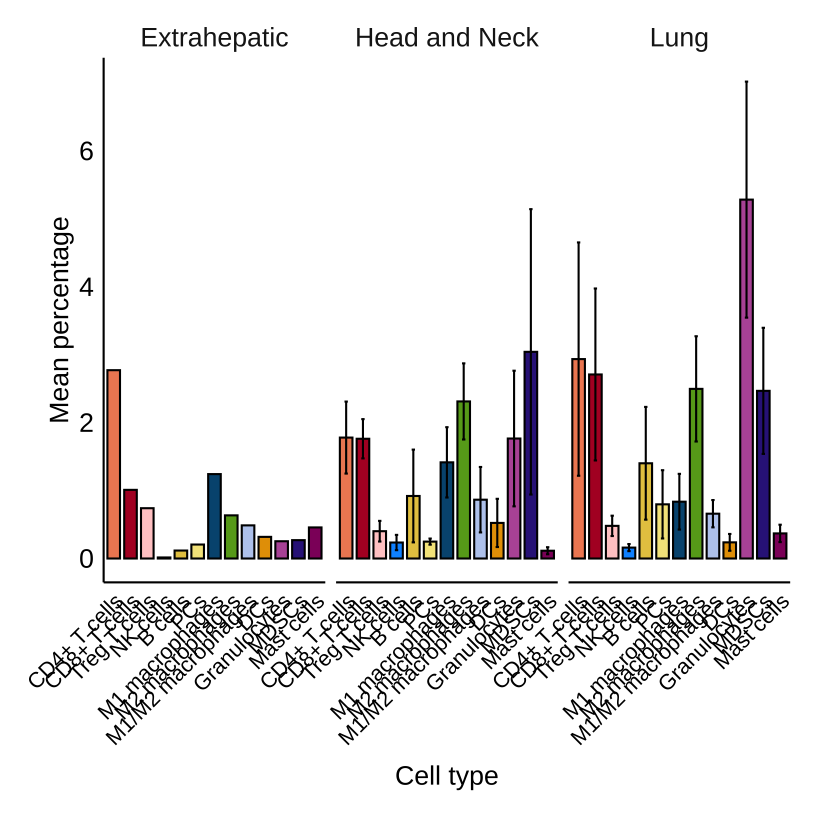

In [294]:
error_plot = ggplot(
  error_bars,
  aes(x = cell_category, y = mean_percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.75, color = "black") +
  geom_errorbar(
    aes(ymin = mean_percentage - se_percentage,
        ymax = mean_percentage + se_percentage),
    width = 0.2
  ) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type",
    y = "Mean percentage",
    fill = "Cell type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 13, colour = "black", angle = 45, hjust = 1),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
    strip.text = element_text(size = 16),
    plot.margin = margin(t = 10, r = 30, b = 30, l = 30)
  ) +
  facet_wrap(~ tumor_site) 

error_plot

#ggsave 
 ggsave(filename = file.path("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/celltype_error_bars_tumor_site.pdf"),
        plot = error_plot,
        width = 10,
        height = 7,
        dpi = 300,
        bg = "white")


## C. Proportions of cell_category_simplified

In [ ]:
cellgroup_percentage_site <- celltype_metadata %>%
  group_by(patient_ID, tumor_site, cell_category_simplified) %>%
  summarise(n = n()) %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100) %>%
  mutate(logn = log2(n+1))  %>%
  filter(cell_category_simplified %in% c("Lymphoid", "Myeloid")) 
cellgroup_percentage_site

## B

In [231]:
celltype_proportions_patient_survival <- celltype_proportions_patient %>%
left_join(
  survival_df %>%
    select(patient_ID, survival_time_months, event, survival_group) %>%
    distinct(),
  by = "patient_ID"
) 
celltype_proportions_patient_survival

patient_ID,cell_category,percentage,tumor_site,is_lung,survival_time_months,event,survival_group
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
NUT_1,B cells,0.25694590,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,CD4+ T cells,0.55026332,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,CD8+ T cells,1.21758193,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,DCs,0.02534020,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,Granulocytes,0.03851657,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,M1 macrophages,1.33385094,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,M1/M2 macrophages,2.24254089,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,M2 macrophages,3.95867995,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor
NUT_1,MDSCs,1.01070344,Head and Neck,Head and Neck/Extrahepatic,170,0,Long-term survivor


## Survival plot for proportions

Joining with `by = join_by(patient_ID)`


Ignoring unknown labels:
• colour : "Actin+ cells"
Ignoring unknown labels:
• colour : "B cells"


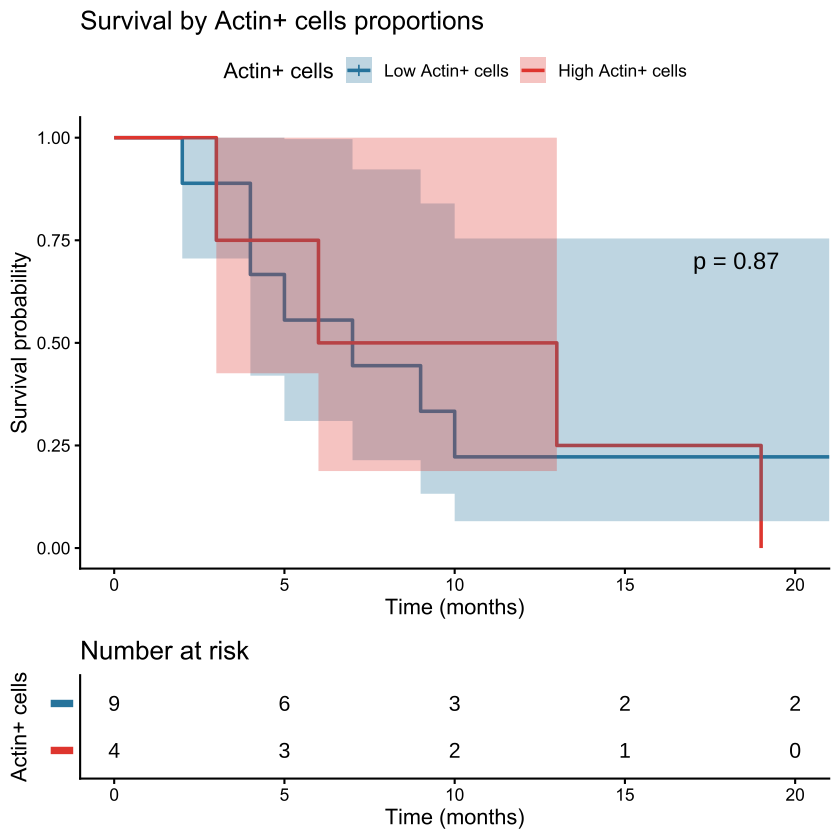

Ignoring unknown labels:
• colour : "CD4+ T cells"


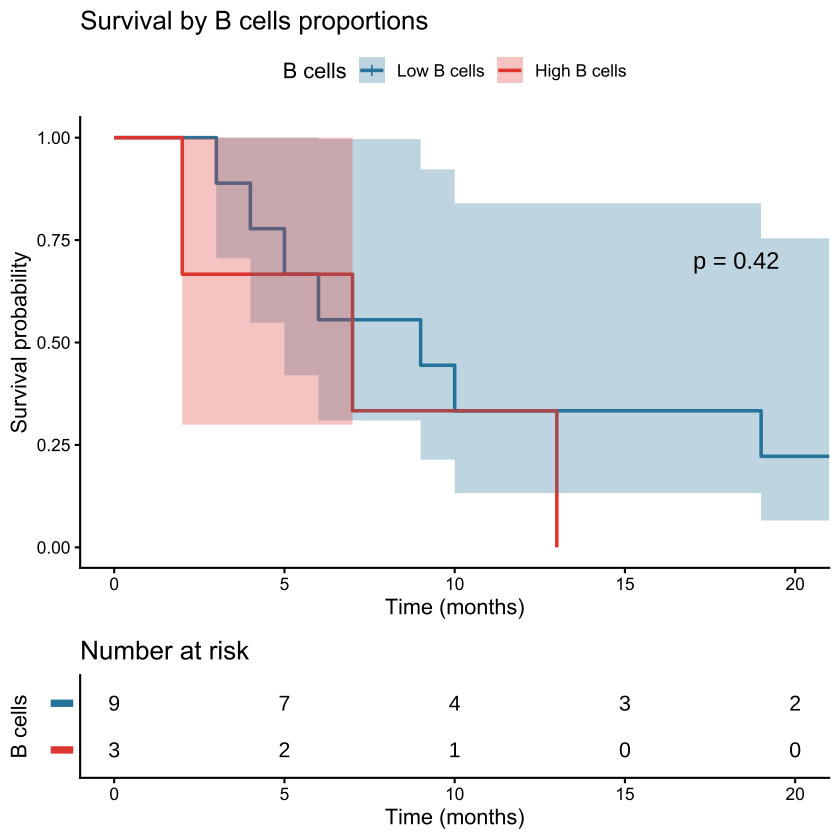

Ignoring unknown labels:
• colour : "CD8+ T cells"


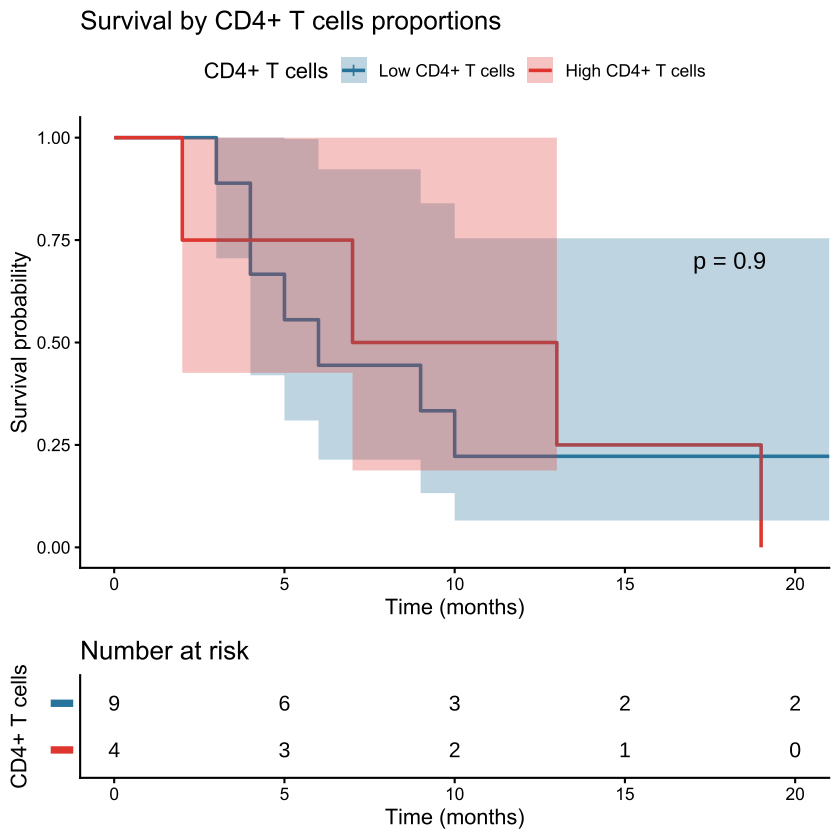

Ignoring unknown labels:
• colour : "DCs"


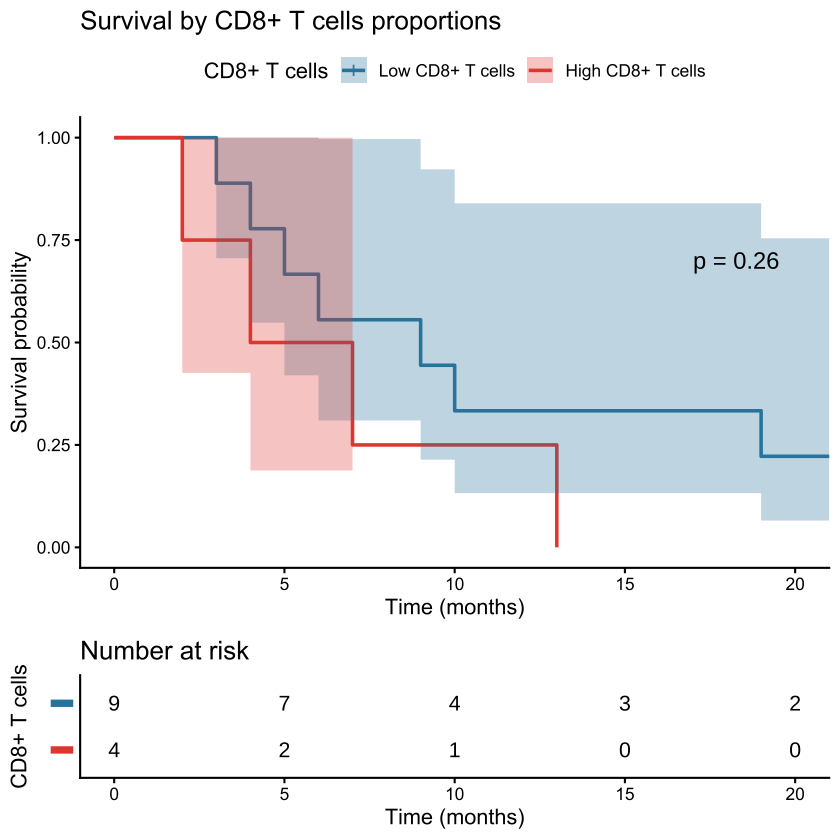

Ignoring unknown labels:
• colour : "Endothelial cells"


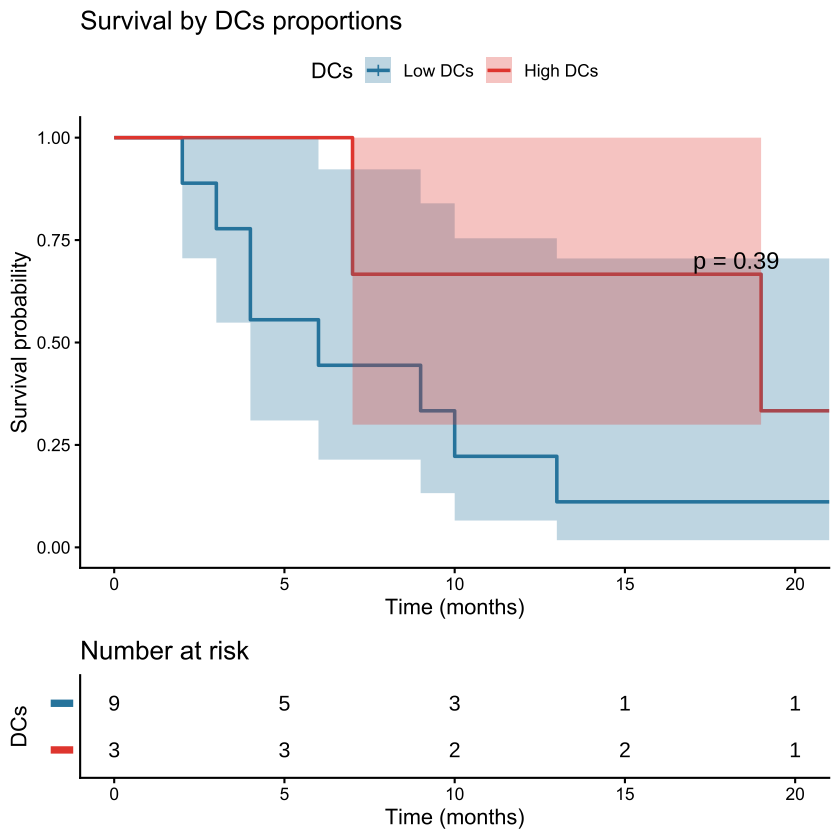

Ignoring unknown labels:
• colour : "Granulocytes"


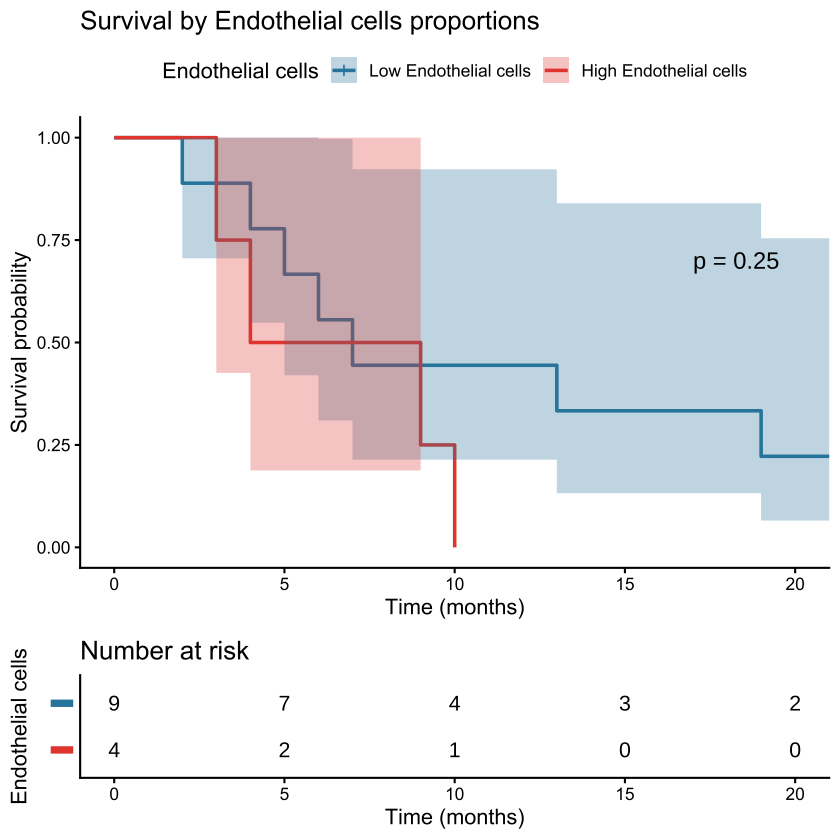

Ignoring unknown labels:
• colour : "Lymphatic endothelial cells"


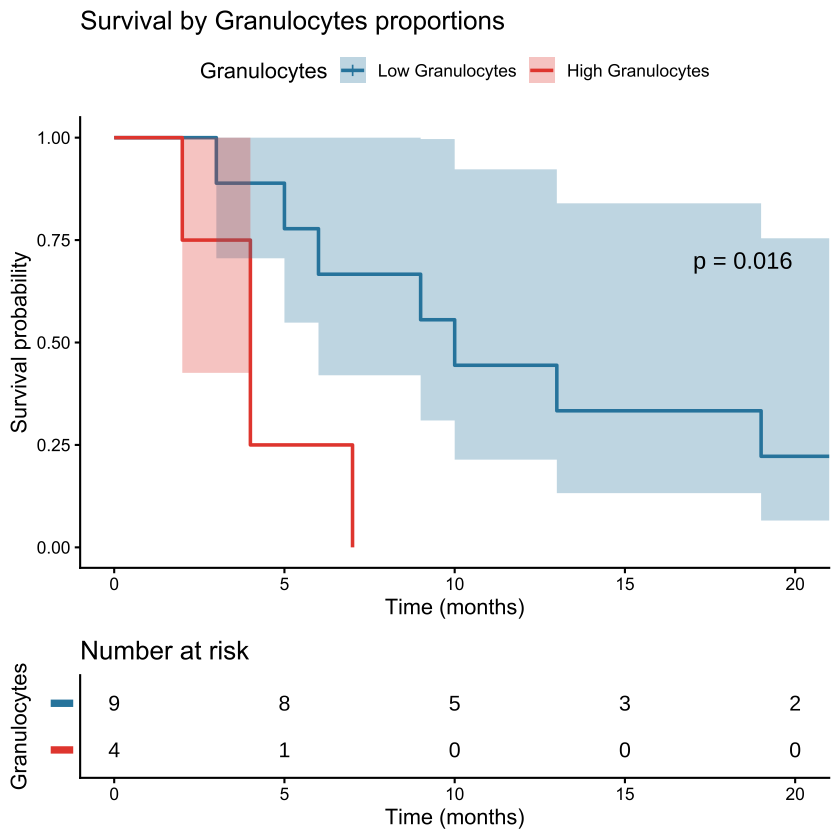

Ignoring unknown labels:
• colour : "M1 macrophages"


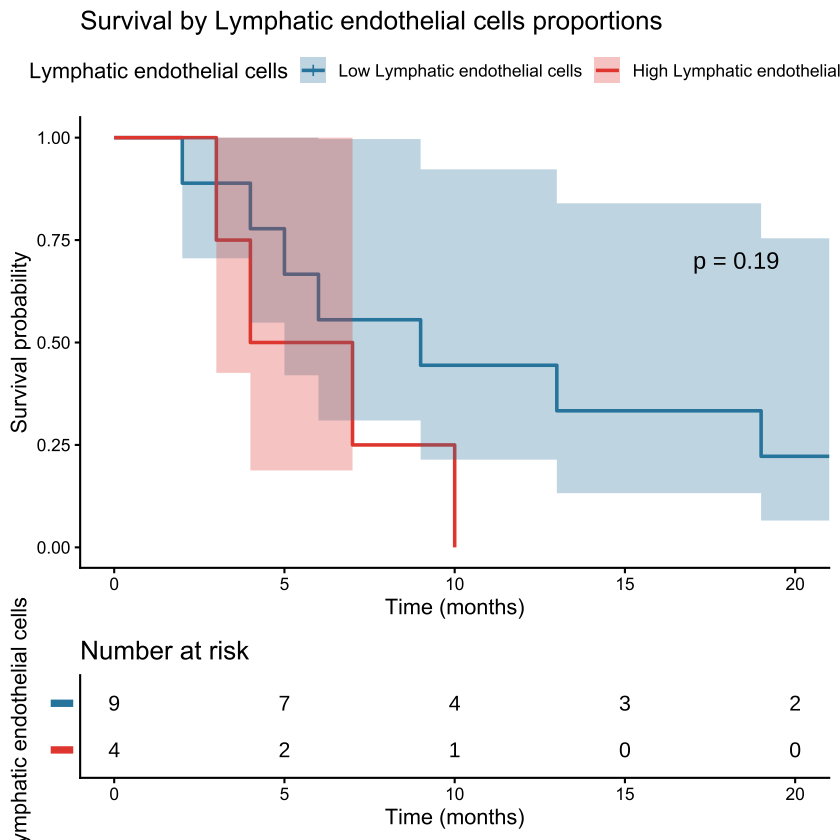

Ignoring unknown labels:
• colour : "M1/M2 macrophages"


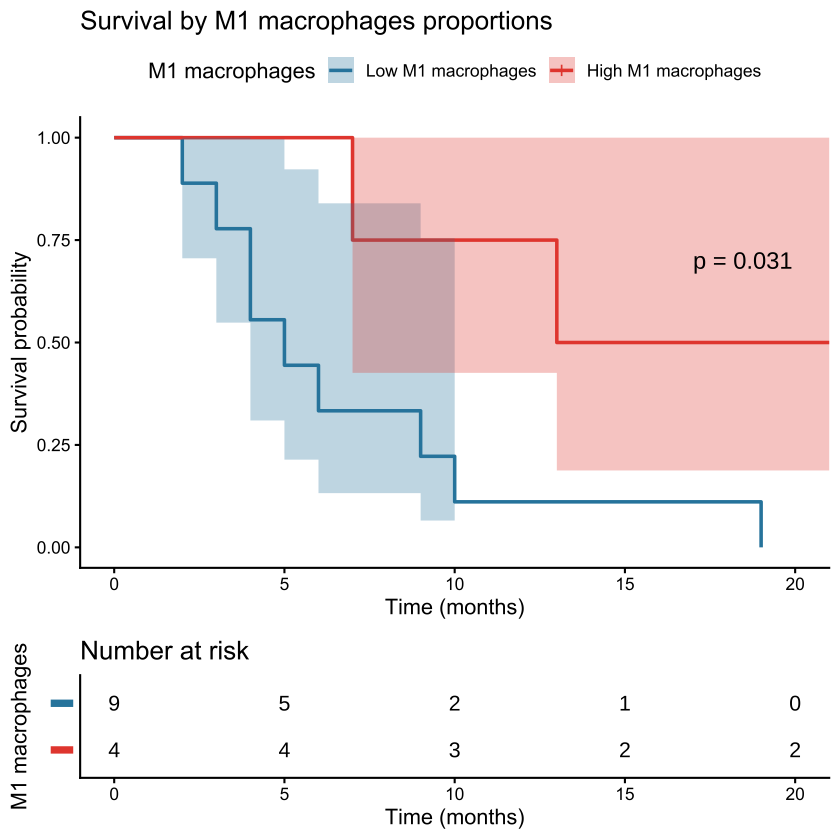

Ignoring unknown labels:
• colour : "M2 macrophages"


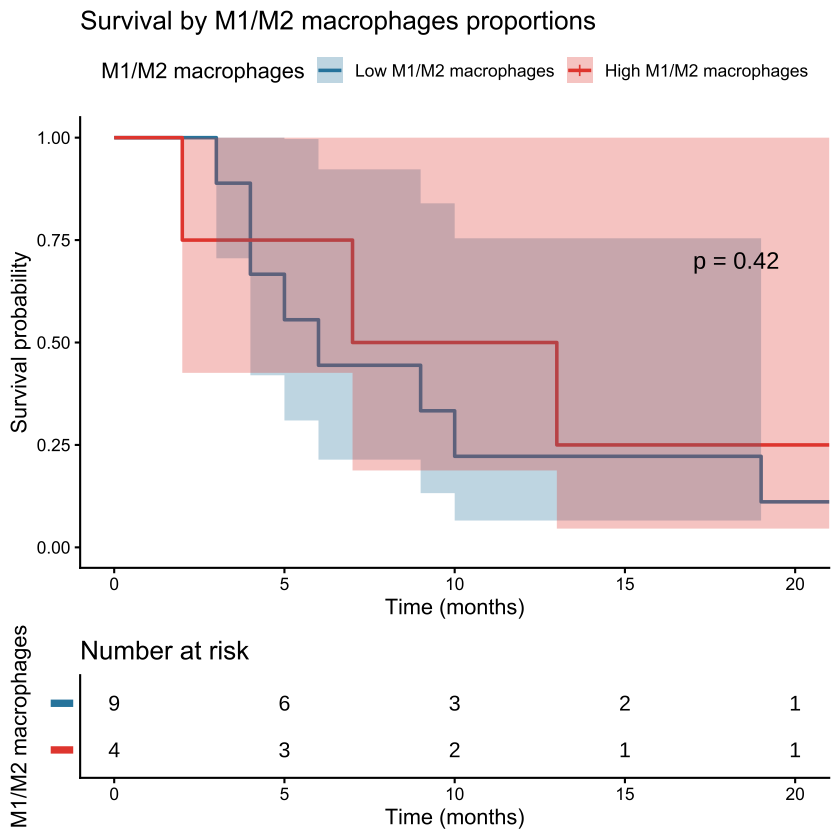

Ignoring unknown labels:
• colour : "MDSCs"


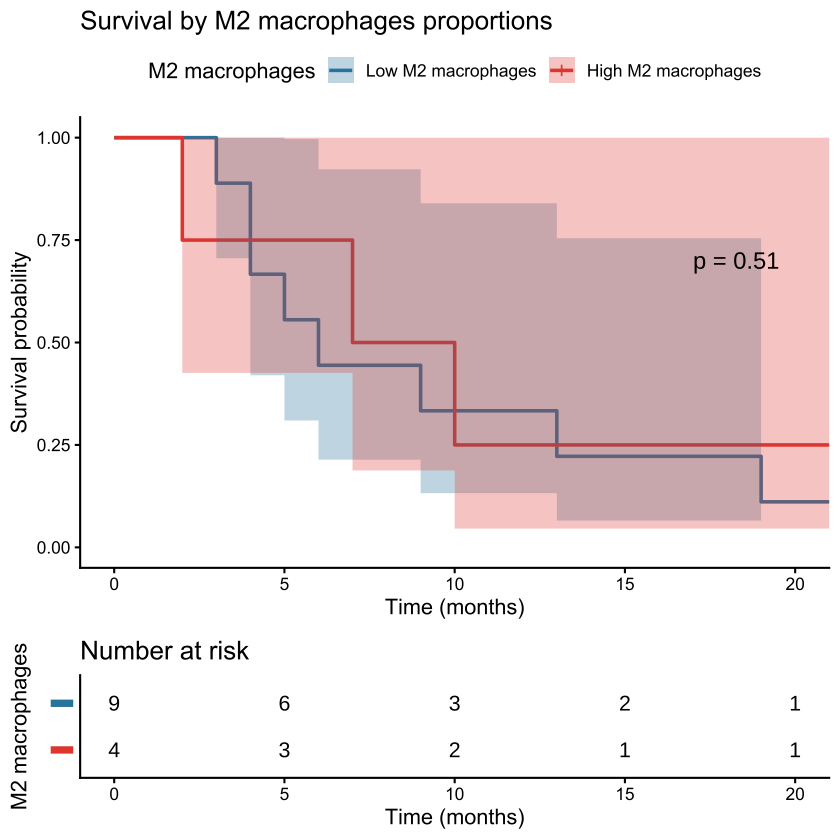

Ignoring unknown labels:
• colour : "Mast cells"


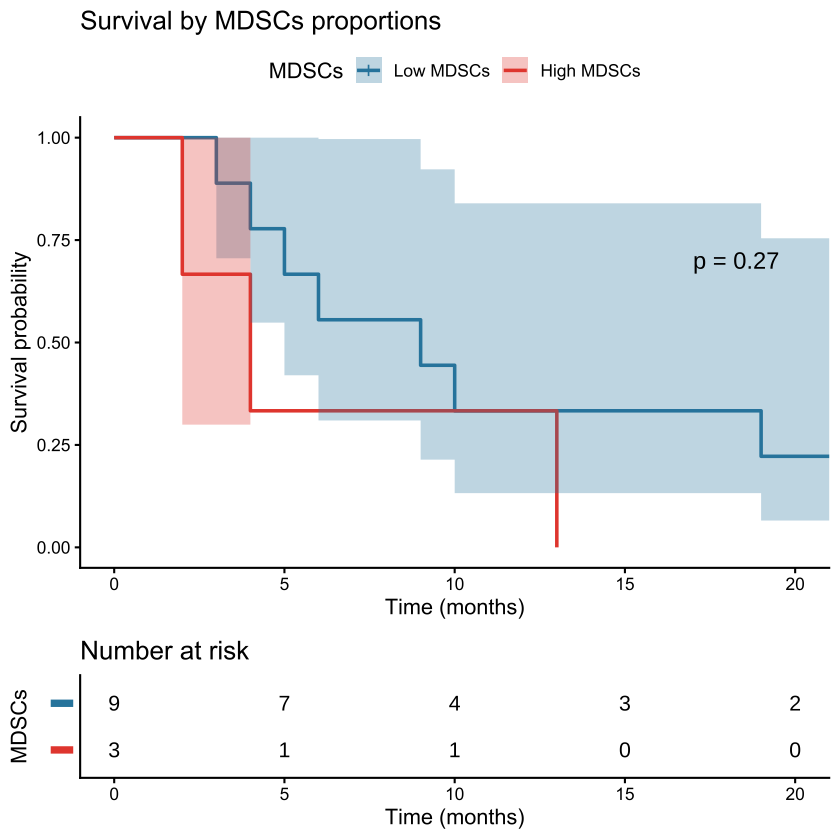

Ignoring unknown labels:
• colour : "NFC"


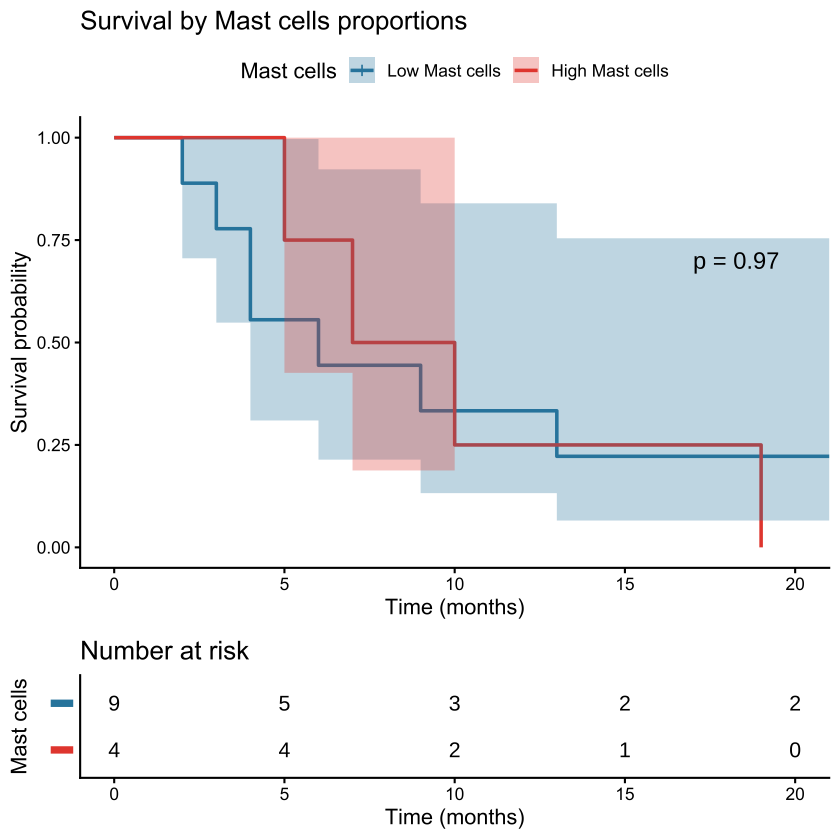

Ignoring unknown labels:
• colour : "NK cells"


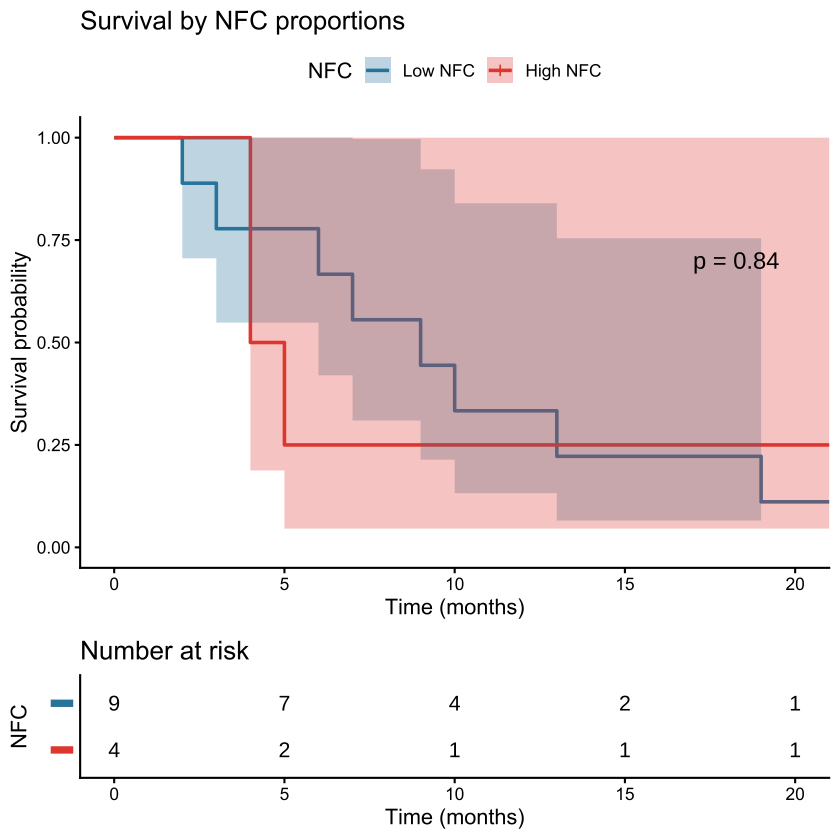

Ignoring unknown labels:
• colour : "PCs"


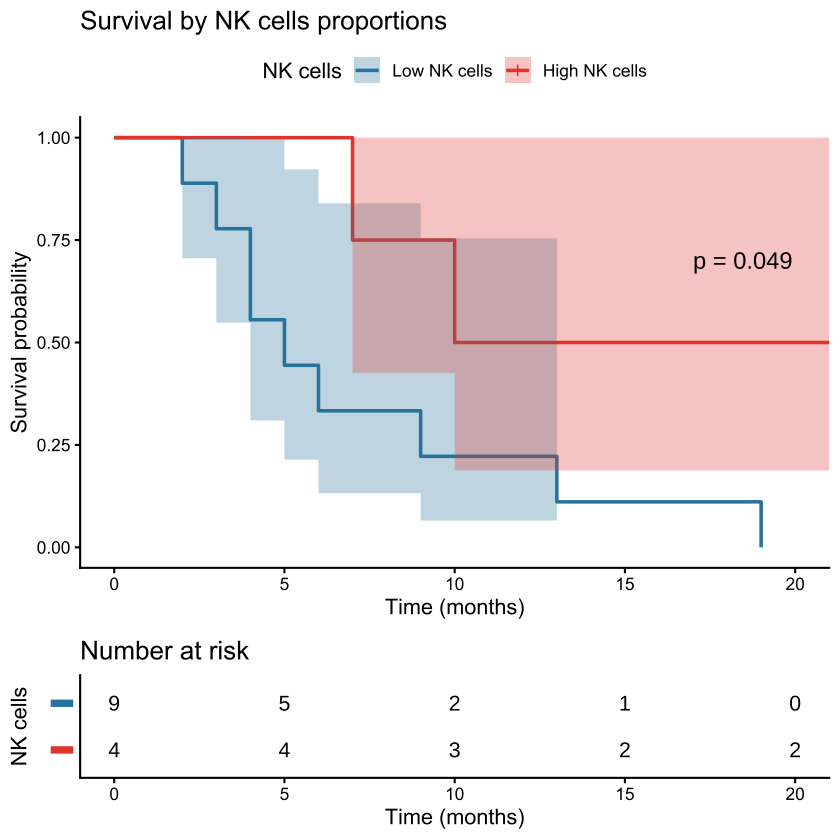

Ignoring unknown labels:
• colour : "Treg T cells"


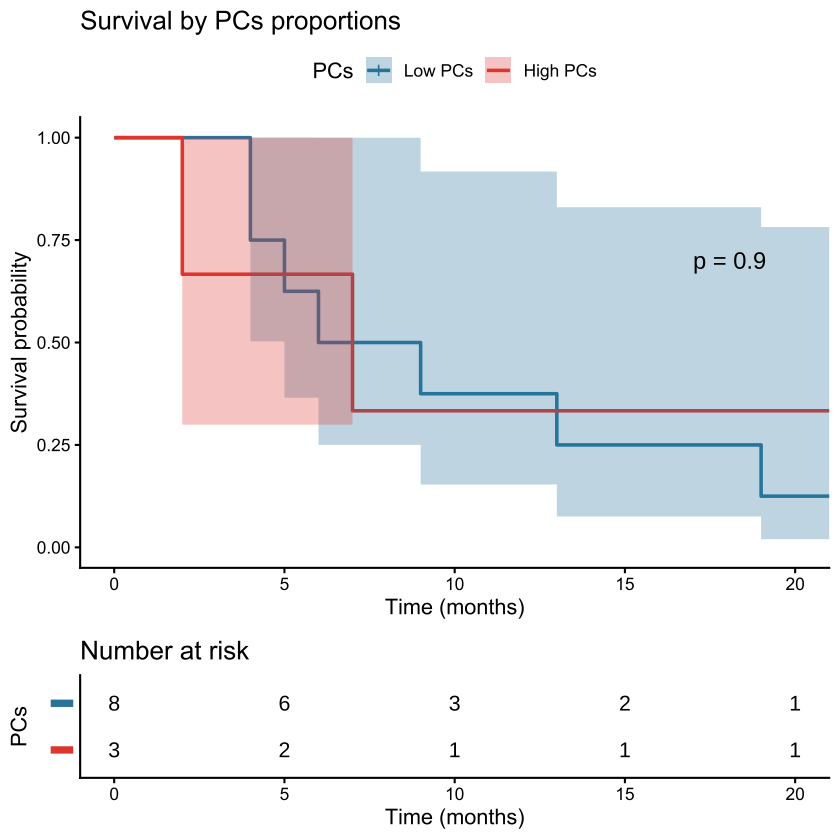

Ignoring unknown labels:
• colour : "Tumor cells"


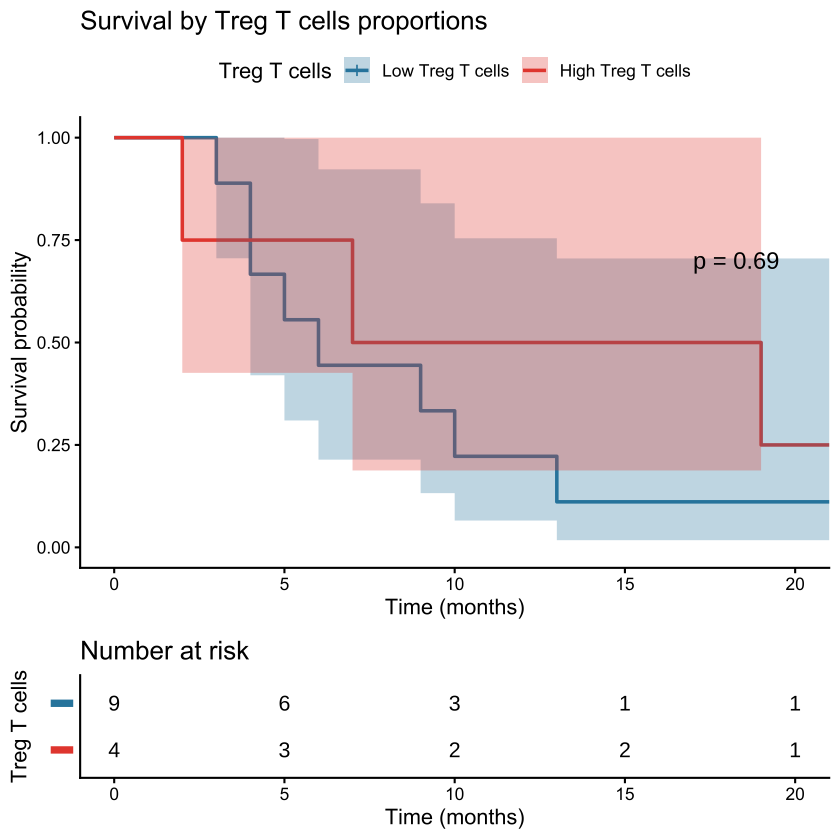

ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m Problem while converting geom to grob.
[36mℹ[39m Error occurred in the 3rd layer.
[1mCaused by error in `draw_group()`:[22m
[1m[22m[33m![39m Aesthetics can not vary along a ribbon: [32mlinewidth[39m and [32mlinetype[39m.


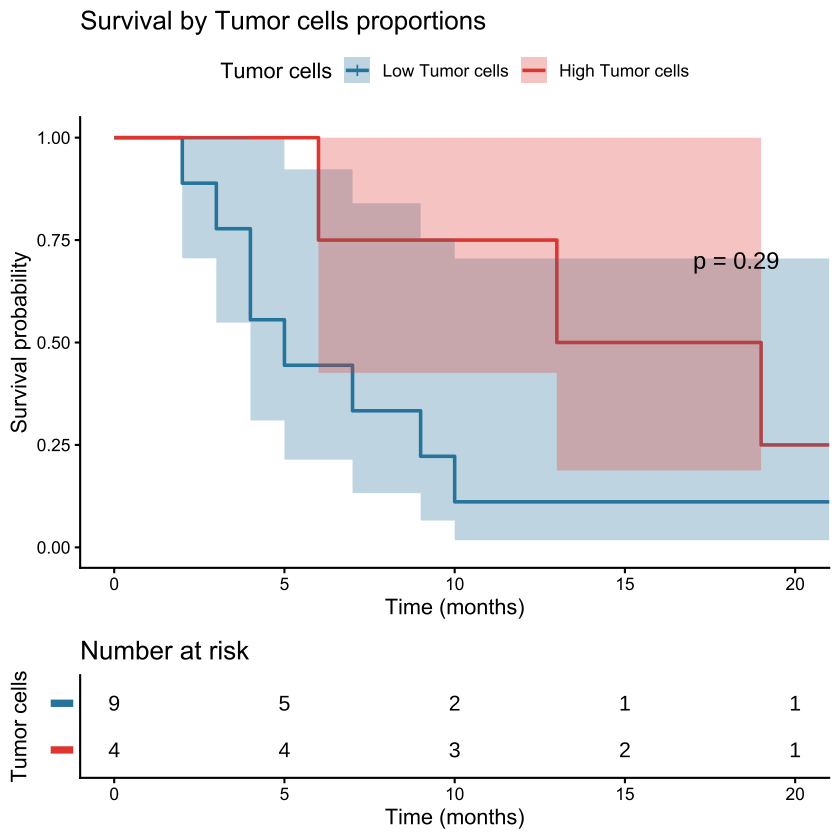

In [357]:
celltype_percentage_patient_survival <- celltype_percentage_patient %>%
    left_join(., survival_df)

for(ct in unique(celltype_percentage_patient_survival$cell_category)){
    df <- celltype_percentage_patient_survival %>%
    filter(cell_category == ct)

    #calculate median percentage for the cell category
    percentage_threshold <- quantile(df$percentage, 0.75, na.rm = TRUE)
    #create a new column that is "High" if the percentage is above the median and "Low" if it is below the median
    df <- df %>%
    mutate(percentage_group = factor(ifelse(percentage >= percentage_threshold, "High", "Low"), levels = c("Low", "High")))
    #perform a survival analysis using the percentage group as the variable of interest
    fit <- survfit(Surv(survival_time_months, event) ~ percentage_group, data = df)
    # Plot
    print(ggsurvplot(
    fit,
    data = df,
    pval = TRUE,
    conf.int = TRUE,
    risk.table = TRUE,
    risk.table.height = 0.25,
    pval.coord = c(17, 0.7),
    xlim = c(0, 20),
    break.time.by = 5,
    palette = c("#2E86AB", "#E74C3C"),
    xlab = "Time (months)",
    ylab = "Survival probability",
    title = paste("Survival by", ct, "proportions"),
    legend.title = ct,
    legend.labs = c(paste("Low", ct), paste("High", ct)),
    risk.table.y.text.col = TRUE,
    risk.table.y.text = FALSE,
    ggtheme = theme_classic(base_size = 13, base_family = "Arial")
  ))
}



In [274]:
cell_types <- unique(celltype_proportions_patient_survival$cell_category)

plots <- lapply(cell_types, function(ct) {
  
  # Filter and create high/low groups
  df <- celltype_proportions_patient_survival %>%
    filter(cell_category == ct) %>%
    mutate(group = factor(
      ifelse(percentage > median(percentage), paste("High", ct), paste("Low", ct)),
      levels = c(paste("Low", ct), paste("High", ct))
    ))
  
  # Fit survival
  fit <- survfit(Surv(survival_time_months, event) ~ group, data = df)
  
  # Plot
  ggsurvplot(
    fit,
    data = df,
    pval = TRUE,
    conf.int = TRUE,
    risk.table = TRUE,
    risk.table.height = 0.25,
    pval.coord = c(17, 0.7),
    xlim = c(0, 20),
    break.time.by = 5,
    palette = c("#2E86AB", "#E74C3C"),
    xlab = "Time (months)",
    ylab = "Survival probability",
    title = paste("Survival by", ct, "proportions"),
    legend.title = ct,
    legend.labs = c(paste("Low", ct), paste("High", ct)),
    risk.table.y.text.col = TRUE,
    risk.table.y.text = FALSE,
    ggtheme = theme_classic(base_size = 13, base_family = "Arial")
  )
})

names(plots) <- cell_types

# pdf("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/survival_by_celltype.pdf", width = 8, height = 6)
# lapply(plots, function(p) print(p))
# dev.off()

for (ct in cell_types) {
  #just make an if function if the celltype is M1/M2 macrophages
  if (ct != "M1/M2 macrophages") {
  filename <- paste0("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/", "survival_", gsub(" ", "_", ct), ".pdf")
  ggsave(
  filename = filename, 
  plot = plots[[ct]]$plot, 
  width = 7, 
  height = 6, 
  dpi = 300)
  filename <- paste0("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/", "survival_table_", gsub(" ", "_", ct), ".pdf")
  ggsave(
  filename = filename, 
  plot = plots[[ct]]$table, 
  width = 7, 
  height = 2, 
  dpi = 300)
  }
else{
  filename <- paste0("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/survival_M1_M2_macrophages.pdf")
  ggsave(
  filename = filename, 
  plot = plots[[ct]]$plot, 
  width = 7, 
  height = 6, 
  dpi = 300)
  filename <- paste0("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig2/survival_table_M1_M2_macrophages.pdf")
  ggsave(
  filename = filename,
  plot = plots[[ct]]$table,
  width = 7,
  height = 2,
  dpi = 300)
}
  }

Ignoring unknown labels:
• colour : "B cells"
Ignoring unknown labels:
• colour : "CD4+ T cells"
Ignoring unknown labels:
• colour : "CD8+ T cells"
Ignoring unknown labels:
• colour : "DCs"
Ignoring unknown labels:
• colour : "Granulocytes"
Ignoring unknown labels:
• colour : "M1 macrophages"
Ignoring unknown labels:
• colour : "M1/M2 macrophages"
Ignoring unknown labels:
• colour : "M2 macrophages"
Ignoring unknown labels:
• colour : "MDSCs"
Ignoring unknown labels:
• colour : "Mast cells"
Ignoring unknown labels:
• colour : "NK cells"
Ignoring unknown labels:
• colour : "PCs"
Ignoring unknown labels:
• colour : "Treg T cells"


In [467]:
distances <- read_csv(file.path("/Users/jawadalaaedeen/Desktop/PhD/NMC/results", "cell_distances_to_tumor_contour.csv"), show_col_types = FALSE) %>%
    mutate(cell_group = case_when(
        cell_category %in% myeloid ~ "Myeloid",
        cell_category %in% lymphoid ~ "Lymphoid",
        cell_category == "Tumor cells" ~ "Tumor",
        TRUE ~ "Non-immune"
    )) %>%
mutate(patient_exp = str_replace(patient_exp, "NMC", "NUT"))



In [468]:
#percentage of each cell typoe in only tumor layers
distances_tumoronly <- distances %>%
filter(tumor_layer %in% c("tumor 0-25 µm", "tumor 25+ µm"))
distances_tumoronly <- distances_tumoronly %>%
group_by(patient_ID, patient_exp, cell_category) %>%
summarise(cell_count = n()) %>%
mutate(percentage = cell_count / sum(cell_count) * 100) %>%
ungroup() %>%
select(!c(patient_ID, cell_count)) %>%
pivot_wider(names_from = cell_category, values_from = percentage, values_fill = 0) %>%
#swithc patient_exp from NMC_ to NUT_
filter(!patient_exp == "NUT_6_ROI6") %>%
mutate(patient_exp = factor(patient_exp, levels = patient_exp_order)) %>%
arrange(patient_exp) %>%
column_to_rownames(var = "patient_exp") %>%
as.matrix()
#arrange columns alphabetically
distances_tumoronly <- distances_tumoronly[, sort(colnames(distances_tumoronly))]
distances_tumoronly

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, patient_exp, and
  cell_category.
ℹ Output is grouped by patient_ID and patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, patient_exp, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Epithelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,Mast cells,MDSCs,NFC,NK cells,PCs,Treg T cells,Tumor cells
NUT_1_ROI1,0.73891626,0.18472906,0.277093596,1.72413793,0.03078818,0.80049261,0.00000000,0.030788177,2.06280788,0.70812808,1.262315271,3.8177340,0.06157635,0.36945813,10.0985222,0.76970443,0.000000000,0.46182266,76.60099
NUT_1_ROI3,1.48255490,0.11147029,0.312116821,0.39014603,0.03344109,0.16720544,0.00000000,0.000000000,0.14491138,1.05896779,2.240552893,2.1848177,0.04458812,1.34879055,9.4526809,0.21179356,0.022294059,0.30096979,80.49270
NUT_2_ROI1,5.07054058,0.00000000,0.195558039,0.46095823,0.04190529,5.36387764,0.06984216,2.346696466,2.12320156,0.27936863,0.446989803,1.0755692,0.16762118,0.64254784,6.8305629,0.04190529,0.000000000,0.09777902,74.74508
NUT_4_ROI9,0.04154549,0.00000000,0.673036975,2.59243872,0.05816369,1.35438305,0.00000000,5.068550062,0.03323639,0.04985459,0.000000000,0.2575821,0.01661820,2.97465725,7.0876610,0.00000000,0.000000000,0.10801828,79.68425
NUT_5_ROI10,0.97360167,0.07187663,0.169890225,0.38552013,0.37898589,1.26764245,1.73810768,1.038944067,0.13068479,0.13721903,0.124150549,0.6403555,0.14375327,1.16309462,7.6319916,0.02613696,0.006534239,0.01960272,83.95191
NUT_5_ROI11,1.34248210,0.02486078,0.164081146,0.54693715,0.01491647,1.14856802,1.85958632,0.626491647,0.04474940,0.01491647,0.114359586,1.0839300,0.06961018,0.83035004,7.4930390,0.07458234,0.000000000,0.01988862,84.52665
NUT_6_ROI5,0.40962990,0.08623787,0.761767876,2.11282788,0.33776500,0.59647862,0.00000000,1.286381603,0.44556234,2.40028746,0.632411067,5.2030183,0.02874596,0.00000000,2.1343874,0.08623787,0.100610852,0.18684872,83.19080
NUT_7_ROI13,0.81428124,0.40714062,0.046977764,0.46977764,0.23488882,0.25054807,0.00000000,0.093955528,0.78296273,0.10961478,1.017851550,2.9909176,0.07829627,3.05355465,1.5502662,0.00000000,0.000000000,0.07829627,88.02067
NUT_7_ROI14,0.25193101,0.16887683,0.227014756,0.10797043,0.15780294,0.38204922,0.00000000,0.024916254,1.09354669,0.03599014,0.124581269,3.4412115,0.04152709,1.33163534,6.3647186,0.00000000,0.000000000,0.08582265,86.16041
NUT_8_ROI17,3.33180498,0.65719089,0.657190891,0.77945896,0.03056702,0.71832493,0.00000000,1.008711600,1.80345407,0.07641755,0.106984564,0.4126547,0.07641755,0.88644353,7.3208009,0.04585053,0.030567018,0.39737124,81.65979


In [464]:
#create a heatmap of the percentages of each cell type in tumor layers using ComplexHeatmap

pct_col <- colorRamp2(c(0,5,20,40,65,85,100),
  c("#FFFFFF","#E1F5EE","#9FE1CB","#5DCAA5","#1D9E75","#0F6E56","#04342C"))

cell_fun <- function(j, i, x, y, width, height, fill) {
  grid.rect(x, y, width, height,
            gp = gpar(col = "black", fill = NA, lwd = 1.2))
  
  val <- distances_tumoronly[i, j]
  if (!is.na(val)) {   
    txt_col <- ifelse(val > 55, "white", "#2C2C2A")
    grid.text(
      sprintf("%.2f", val),
      x, y,
      gp = gpar(
        fontsize  = 7,
        col       = txt_col,
        fontface  = "plain"
      )
    )
  }
}

tumor_layer_heatmap <- Heatmap(distances_tumoronly, 
        name = "Percentage in tumor layers", 
        show_row_names = TRUE, 
        show_column_names = TRUE,
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        col = pct_col,
        cell_fun = cell_fun,
        row_names_gp    = gpar(fontsize = 10),
        column_names_gp = gpar(fontsize = 10),
        row_names_side = "left",
      column_names_rot = 45,
    heatmap_legend_param = list(
    title          = "Percentage in\ntumor contour",
    title_gp       = gpar(fontsize = 10),
    labels_gp      = gpar(fontsize = 10),
    at             = c(0, 25, 50, 75, 100),
    labels         = c("0%", "25%", "50%", "75%", "100%"),
    legend_height  = unit(4, "cm"),
    border         = "grey60"
  )
)
#save heatmap 
pdf("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig3/heatmap_percentage_in_tumor_layers.pdf", width = 12, height = 7)
draw(tumor_layer_heatmap)
dev.off()


agg_record_1096249666 
                    2

In [475]:
#percentage of each cell type in each layer
distances_percentage_layer <- distances %>%
group_by(patient_exp, cell_category, tumor_layer) %>%
summarise(cell_count = n()) %>%
group_by(patient_exp, tumor_layer) %>%
mutate(percentage = cell_count / sum(cell_count) * 100) %>%
ungroup() %>%
select(!cell_count) %>%
mutate(patient_exp = factor(patient_exp, levels = patient_exp_order)) %>%
arrange(patient_exp) %>%
filter(cell_category %in% c(lymphoid, myeloid))

distances_percentage_layer

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, cell_category, and
  tumor_layer.
ℹ Output is grouped by patient_exp and cell_category.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, cell_category, tumor_layer))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


patient_exp,cell_category,tumor_layer,percentage
<fct>,<chr>,<chr>,<dbl>
NUT_1_ROI1,B cells,stroma 0-25 µm,0.44052863
NUT_1_ROI1,B cells,stroma 25-50 µm,1.28301887
NUT_1_ROI1,B cells,stroma 50-75 µm,0.14471780
NUT_1_ROI1,B cells,stroma 75-100 µm,0.34364261
NUT_1_ROI1,B cells,tumor 0-25 µm,0.17825312
NUT_1_ROI1,B cells,tumor 25+ µm,0.19920319
NUT_1_ROI1,CD4+ T cells,stroma 0-25 µm,1.02790015
NUT_1_ROI1,CD4+ T cells,stroma 25-50 µm,0.30188679
NUT_1_ROI1,CD4+ T cells,stroma 50-75 µm,0.72358900


In [488]:
layer_order <- c(
  "stroma distal",
  "stroma 75-100 µm",
  "stroma 50-75 µm",
  "stroma 25-50 µm",
  "stroma 0-25 µm",
  "tumor 0-25 µm",
  "tumor 25+ µm"
)

distances_percentage_layer <- distances_percentage_layer %>%
  mutate(tumor_layer = factor(tumor_layer, levels = layer_order))

# add color column by merging palette
color_df <- tibble(
  cell_category = names(full_palette),
  cell_color    = unlist(full_palette)
)

plot_df <- distances_percentage_layer %>%
  left_join(color_df, by = "cell_category")

p <- ggplot(plot_df, aes(x = tumor_layer, y = percentage, group = patient_exp)) +
  geom_line(aes(color = cell_category), alpha = 0.4, linewidth = 0.5) +
  geom_point(aes(color = cell_category), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = full_palette) +
  facet_wrap(~ cell_category, ncol = 4, scales = "free_y") +
  theme_classic() +
  theme(
    panel.border    = element_rect(color = "black", fill = NA, linewidth = 1),
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x    = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    axis.text.y     = element_text(size = 11, colour = "black"),
    axis.title.y    = element_text(size = 20, colour = "black", margin = margin(r = 10)),
    axis.line       = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks      = element_line(linewidth = 0.5, colour = "black"),
    strip.text      = element_text(size = 11, hjust = 0.5),
    strip.background = element_blank(),
    legend.position = "none" ,
    panel.spacing.y  = unit(2, "cm")
  ) +
  labs(
    x = "Distance interval",
    y = "% of cells in layer"
  )

ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig4/percentage_per_layer.pdf",
  plot     = p,
  width    = 16,
  height   = 12,
  device   = "pdf"
)


In [497]:
#calculate infiltration, so percentage of cells in each patient that are within the stroma_tumor, tumor_0_25, and tumor_25+ layers
myeloid_select <- c("Granulocytes", "M2 macrophages", "MDSCs")
non_contour_cells <- distances %>%
filter(!tumor_layer %in% c("stroma 0-25 µm", "tumor 0-25 µm", "tumor 25+ µm")) %>%
select(patient_exp, patient_ID, cell_category, tumor_total_area_um2, non_tumor_area_um2) %>%
group_by(patient_exp, patient_ID, cell_category, tumor_total_area_um2, non_tumor_area_um2) %>%
summarise(n_outside = n()) %>%
ungroup()

infiltration_df <- distances %>%
    filter(tumor_layer %in% c("stroma 0-25 µm", "tumor 0-25 µm", "tumor 25+ µm")) %>%
    group_by(patient_exp, patient_ID, cell_category) %>%
    summarise(n_infiltrating = n()) %>%
    ungroup() %>%
    left_join(
        non_contour_cells,
        by = c("patient_exp", "patient_ID", "cell_category")
        ) %>%
    mutate(n_infiltrating_normalized = (n_infiltrating / sqrt(tumor_total_area_um2)),
            n_outside_normalized = (n_outside / sqrt(non_tumor_area_um2))) %>%
    mutate(infiltration_ratio = log2(n_infiltrating_normalized / n_outside_normalized)) %>%
    select(!patient_exp) %>%
    group_by(patient_ID, cell_category) %>%
    summarise(median_infiltration = median(infiltration_ratio, na.rm = TRUE)) %>%
    mutate(patient_ID = str_replace(patient_ID, "NMC", "NUT")) %>%
    filter(cell_category %in% c(myeloid, lymphoid)) %>%
    #arrange patient_ID according to patient_ID_order
    ungroup() %>%
    filter(cell_category %in% c(myeloid_select, "CD8+ T cells", "CD4+ T cells")) %>%
    mutate(patient_ID = factor(patient_ID, levels = patient_ID_survival_order),
    cell_category = factor(cell_category, levels = c("CD8+ T cells", "CD4+ T cells", myeloid_select))) %>%
    arrange(patient_ID, cell_category)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, cell_category,
  tumor_total_area_um2, and non_tumor_area_um2.
ℹ Output is grouped by patient_exp, patient_ID, cell_category, and
  tumor_total_area_um2.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category,
  tumor_total_area_um2, non_tumor_area_um2))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp, patient_ID, and
  cell_category.
ℹ Output is grouped by patient_exp and patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, patient_ID, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.


In [505]:
for(ct in unique(infiltration_survival$cell_category)){
  
  df <- infiltration_survival %>%
    filter(cell_category == ct) %>%
    mutate(
      infiltration_group = factor(
        ifelse(median_infiltration >= 0, "High infiltration", "Low infiltration"),
        levels = c("Low infiltration", "High infiltration")
      )
    )
  
  if(length(unique(df$infiltration_group)) < 2) next
  
  # check minimum group size — conf.int breaks with n=1
  min_group_n <- df %>%
    count(infiltration_group) %>%
    pull(n) %>%
    min()
  
  show_ci <- min_group_n >= 3
  
  fit <- survfit(Surv(survival_time_months, event) ~ infiltration_group, data = df)
  
  surv_plot <- ggsurvplot(
    fit,
    data              = df,
    pval              = TRUE,
    conf.int          = show_ci,   # ← off when a group is too small
    risk.table        = TRUE,
    risk.table.height = 0.25,
    pval.coord        = c(17, 0.7),
    xlim              = c(0, 20),
    break.time.by     = 5,
    palette           = c("#2E86AB", "#E74C3C"),
    xlab              = "Time (months)",
    ylab              = "Survival probability",
    title             = paste("Survival by", ct, "tumor infiltration"),
    legend.title      = ct,
    legend.labs       = c(paste("Low", ct, "infiltration"),
                          paste("High", ct, "infiltration")),
    risk.table.y.text.col = TRUE,
    risk.table.y.text     = FALSE,
    ggtheme           = theme_classic(base_size = 13, base_family = "Arial")
  )

  filename <- paste0("/Users/jawadalaaedeen/Desktop/images_for_figures/supp_fig4/", "survival_infiltration_", ct, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$plot, 
    width = 7, 
    height = 6, 
    dpi = 300)

}